In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

In [3]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import acovf, acf, pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot
from statsmodels.tsa.seasonal import seasonal_decompose 
from statsmodels.tsa.arima.model import ARIMA

from pmdarima import auto_arima

from sklearn.metrics import mean_squared_error

import tensorflow as tf

#### The goal is to predict offshore wind generation for Denmark over future horizons using both classical modeling and deep learning, then compare how well each approach captures the underlying temporal dynamics.

#### Load the EMHIRES dataset which provides hourly offshore wind power production time series across multiple European countries over roughly 30 years.

In [4]:
df = pd.read_csv('data/TS.CF.OFFSHORE.30yr.date.txt', sep='\t', index_col='Date', date_format='%d/%m/%Y %H:%M', parse_dates=True)

In [5]:
df.head()

,Time step,Year,Month,Day,Hour,BE,DK,DE,NL,UK
Date,,,,,,,,,,
1986-01-01 00:00:00,1,1986,1,1,0,0.65206,0.69450,0.64662,0.65980,0.44185
1986-01-01 01:00:00,2,1986,1,1,1,0.60341,0.67387,0.63756,0.64448,0.42026
1986-01-01 02:00:00,3,1986,1,1,2,0.52151,0.65254,0.62826,0.62745,0.38456
1986-01-01 03:00:00,4,1986,1,1,3,0.46460,0.64079,0.62038,0.60343,0.34960
1986-01-01 04:00:00,5,1986,1,1,4,0.41794,0.62641,0.61222,0.57977,0.31395


In [6]:
df.index.freq='h'

In [7]:
df.isnull().sum()

Time step    0
Year         0
Month        0
Day          0
Hour         0
BE           0
DK           0
DE           0
NL           0
UK           0
dtype: int64

#### Filter the the data to Denmark's offshore wind production and resample to a monthly time scale. Aggregating to monthly averages helps emphasize long-range seasonal structure.

In [8]:
dfm = pd.DataFrame(df['DK'].resample(rule='ME').apply('mean'))

In [9]:
dfm.index.freq = 'ME'

array([[<Axes: title={'center': 'DK'}>]], dtype=object)

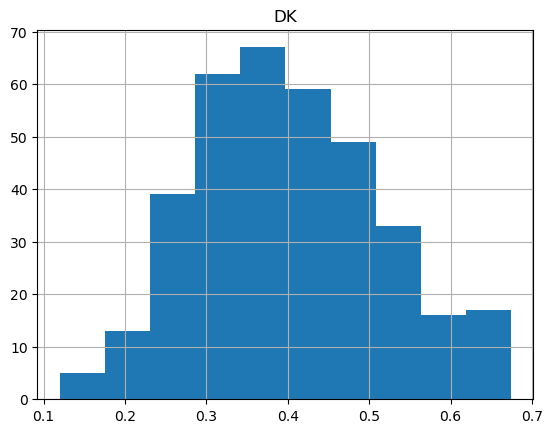

In [10]:
dfm.hist()

#### After resampling, the monthly Denmark series shows a pronounced seasonal pattern: offshore wind power tends to be lower during summer months and higher during winter months.

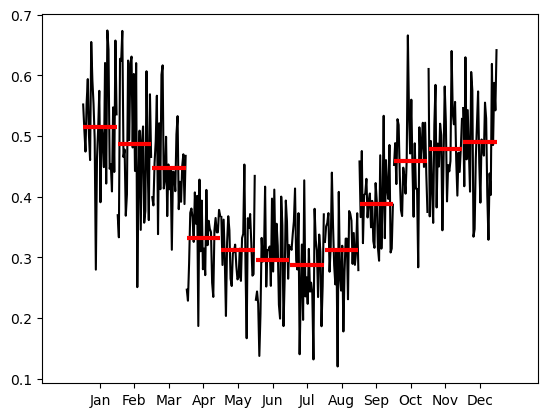

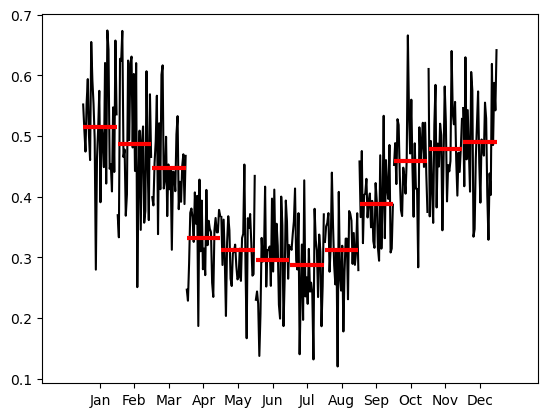

In [11]:
month_plot(dfm)

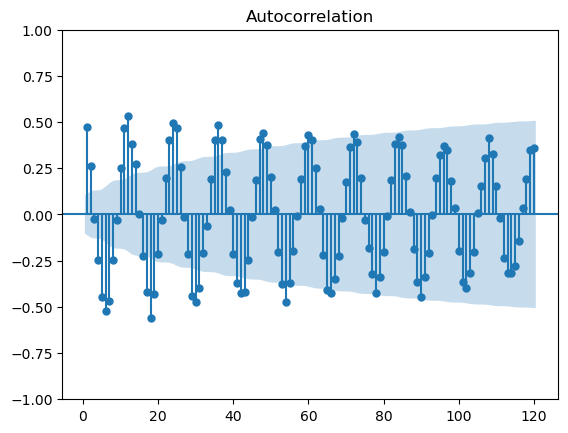

In [12]:
plot_acf(dfm, zero=False, lags=120);

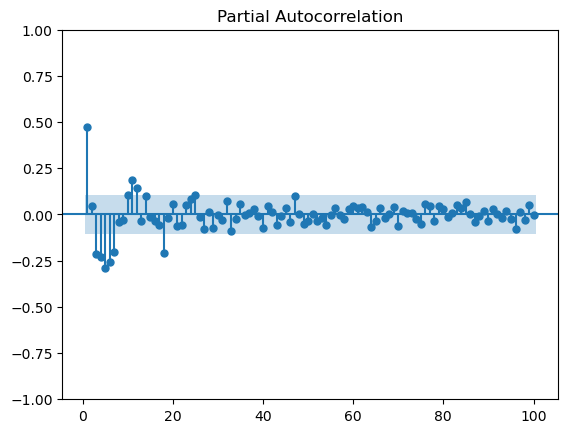

In [13]:
plot_pacf(dfm, zero=False, lags=100);

In [14]:
adfuller(dfm)

(np.float64(-5.237704185122206),
 np.float64(7.360408296295937e-06),
 17,
 342,
 {'1%': np.float64(-3.4496162602188187),
  '5%': np.float64(-2.870028369720798),
  '10%': np.float64(-2.5712922615505627)},
 np.float64(-727.4877034491185))

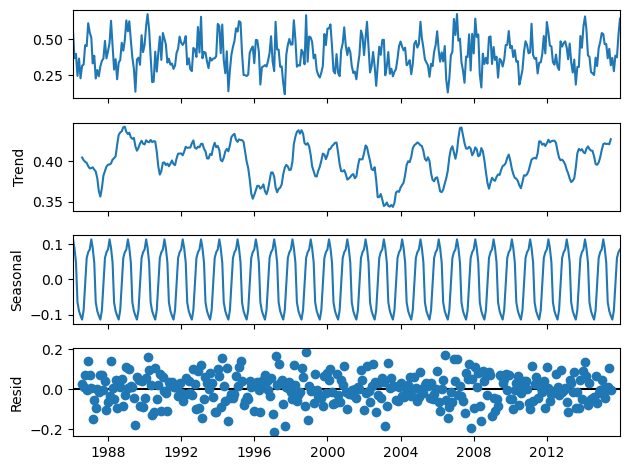

In [15]:
seasonal_decompose(dfm, model='add').plot();

#### Select optimal ARIMA model using auto_arima.

In [16]:
autofit = auto_arima(dfm, m=12, 
                     start_p=1, start_q=1, max_p=5, max_q=5,
                     start_P=1, start_Q=1, max_P=3, max_Q=3,
                     seasonal=True, trace=True)
autofit.summary()

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,0,1)[12] intercept   : AIC=inf, Time=0.96 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=-545.009, Time=0.05 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=-687.450, Time=0.57 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=-656.319, Time=0.19 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=392.099, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=-636.142, Time=0.08 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=-692.128, Time=2.38 sec
 ARIMA(1,0,0)(3,0,0)[12] intercept   : AIC=inf, Time=6.83 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=-765.736, Time=1.94 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.53 sec
 ARIMA(1,0,0)(3,0,1)[12] intercept   : AIC=-760.511, Time=6.33 sec
 ARIMA(1,0,0)(2,0,2)[12] intercept   : AIC=inf, Time=2.26 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=inf, Time=1.83 sec
 ARIMA(1,0,0)(3,0,2)[12] intercept   : AIC=inf, Time=6.61 sec
 ARIMA(0,0,0)(2,0,1)[12] intercept   : AIC=inf, Ti

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  360
Model:             SARIMAX(1, 0, 0)x(2, 0, [1], 12)   Log Likelihood                 388.868
Date:                              Sun, 28 Jun 2026   AIC                           -765.736
Time:                                      22:18:19   BIC                           -742.420
Sample:                                  01-31-1986   HQIC                          -756.465
                                       - 12-31-2015                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0018      0.002      1.014      0.311      -0.002       0.005
ar.L1          0.0418      0.047      0.881      0.378      -0.051       0.135
ar.S.L12       0.9516      0.064     14.808      0.000       0.826       1.078
ar.S.L24       0.0436      0.063      0.695      0.487      -0.079       0.166
ma.S.L12      -0.8688      0.053    -16.501      0.000      -0.972      -0.766
sigma2         0.0063      0.000     13.469      0.000       0.005       0.007
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):                 1.52
Prob(Q):                              0.79   Prob(JB):                         0.47
Heteroskedasticity (H):               0.99   Skew:                             0.02
Prob(H) (two-sided):                  0.94   Kurtosis:                         3.32
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### Split data into train/test sets, fit training set to ARIMA model.

In [17]:
x = int(np.ceil(len(dfm)*0.65))
dfm_train = dfm[0:x]
dfm_test = dfm[x:]

In [18]:
model = ARIMA(dfm_train, order=(1,0,0), seasonal_order=(2,0,1,12))
results = model.fit(method_kwargs={'maxiter':1000})
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                 DK   No. Observations:                  234
Model:             ARIMA(1, 0, 0)x(2, 0, [1], 12)   Log Likelihood                 249.069
Date:                            Sun, 28 Jun 2026   AIC                           -486.138
Time:                                    22:18:21   BIC                           -465.406
Sample:                                01-31-1986   HQIC                          -477.778
                                     - 06-30-2005                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3995      0.026     15.215      0.000       0.348       0.451
ar.L1          0.1022      0.059      1.725      0.085      -0.014       0.218
ar.S.L12       1.0377      0.083     12.445      0.000       0.874       1.201
ar.S.L24      -0.0397      0.080     -0.498      0.619      -0.196       0.116
ma.S.L12      -0.9415      0.124     -7.574      0.000      -1.185      -0.698
sigma2         0.0063      0.001      8.285      0.000       0.005       0.008
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 3.65
Prob(Q):                              0.93   Prob(JB):                         0.16
Heteroskedasticity (H):               0.83   Skew:                             0.05
Prob(H) (two-sided):                  0.41   Kurtosis:                         3.60
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### Evaluate long-horizon forecasting on the test set.

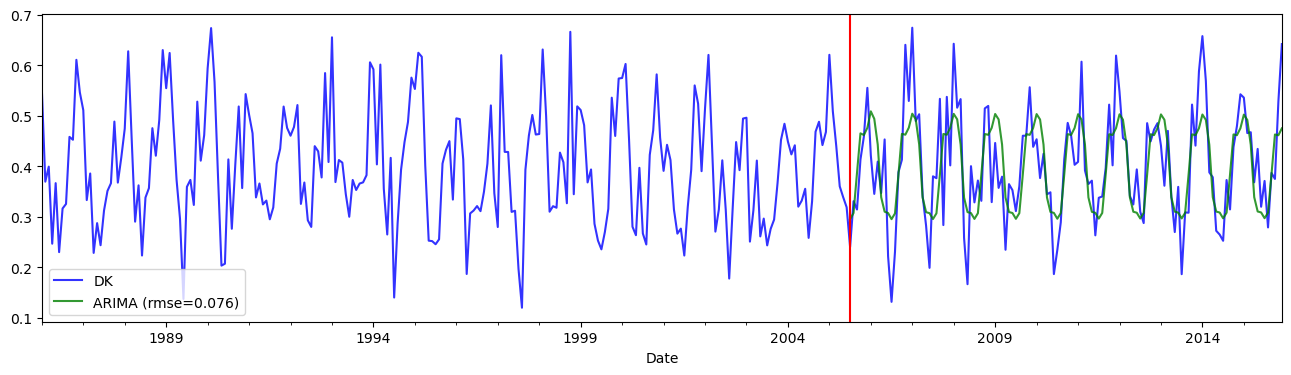

In [19]:
start = len(dfm_train)
end = len(dfm_train)+len(dfm_test)-1
dfm_pred = results.predict(start=start, end=end)
dfm_pred = dfm_pred.rename(f'ARIMA (rmse={np.sqrt(mean_squared_error(dfm_test, dfm_pred)):2.2})')

fig = plt.figure(figsize=(16,4))
ax = plt.gca()

dfm.plot(color='blue', alpha=0.8, ax=ax)
dfm_pred.plot(legend=True, alpha=0.8, color='green', ax=ax)
plt.axvline(dfm_test.index[0], color='red')

#### Shift to hourly frequency and restrict the dataset to the last 10 days.

In [20]:
dfh = pd.DataFrame(df['DK'])
dfh = dfh.tail(24*10)

In [21]:
dfh.index.freq='h'

#### No clear daily (24-hour) pattern is observed. Daily effects are weak and are largely masked by variability spanning multiple days, indicating that simple daily seasonality alone may not fully explain the short-term signal.

<Axes: xlabel='Date'>

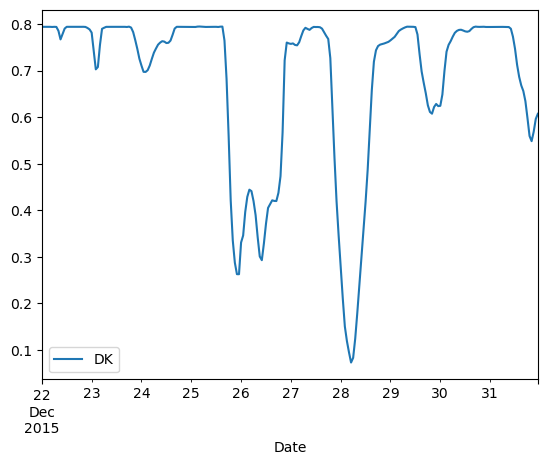

In [22]:
dfh.plot()

In [23]:
adfuller(dfh)

(np.float64(-3.3037172465923192),
 np.float64(0.014713128938376138),
 2,
 237,
 {'1%': np.float64(-3.4582467982399105),
  '5%': np.float64(-2.8738137461081323),
  '10%': np.float64(-2.5733111490323846)},
 np.float64(-1214.0596142994696))

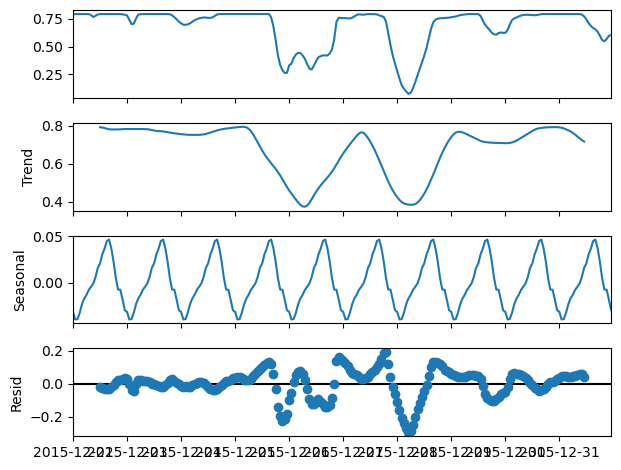

In [24]:
seasonal_decompose(dfh, model='add').plot();

#### Select optimal ARIMA model using auto_arima.

In [25]:
autofit = auto_arima(dfh, m=24, 
                     start_p=1, start_q=1, max_p=3, max_q=3,
                     start_P=1, start_Q=1, max_P=1, max_Q=1,
                     seasonal=True, trace=True)
autofit.summary()

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,0,1)[24] intercept   : AIC=inf, Time=1.56 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=-142.835, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=-993.858, Time=1.12 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=inf, Time=0.84 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=514.755, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[24] intercept   : AIC=-976.214, Time=0.05 sec
 ARIMA(1,0,0)(1,0,1)[24] intercept   : AIC=-992.005, Time=1.00 sec
 ARIMA(1,0,0)(0,0,1)[24] intercept   : AIC=-993.652, Time=0.42 sec
 ARIMA(0,0,0)(1,0,0)[24] intercept   : AIC=-159.246, Time=0.67 sec
 ARIMA(2,0,0)(1,0,0)[24] intercept   : AIC=-1281.866, Time=1.57 sec
 ARIMA(2,0,0)(0,0,0)[24] intercept   : AIC=-1282.775, Time=0.09 sec
 ARIMA(2,0,0)(0,0,1)[24] intercept   : AIC=-1281.960, Time=0.94 sec
 ARIMA(2,0,0)(1,0,1)[24] intercept   : AIC=inf, Time=1.21 sec
 ARIMA(3,0,0)(0,0,0)[24] intercept   : AIC=-1304.141, Time=0.10 sec
 ARIMA(3,0,0)(1,0,0)[24] interc

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  240
Model:               SARIMAX(3, 0, 0)   Log Likelihood                 657.071
Date:                Sun, 28 Jun 2026   AIC                          -1304.141
Time:                        22:18:36   BIC                          -1286.738
Sample:                    12-22-2015   HQIC                         -1297.129
                         - 12-31-2015                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0135      0.004      3.638      0.000       0.006       0.021
ar.L1          2.0856      0.033     63.171      0.000       2.021       2.150
ar.L2         -1.4130      0.074    -19.194      0.000      -1.557      -1.269
ar.L3          0.3077      0.046      6.743      0.000       0.218       0.397
sigma2         0.0002   1.07e-05     22.299      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.19   Jarque-Bera (JB):              1533.05
Prob(Q):                              0.66   Prob(JB):                         0.00
Heteroskedasticity (H):               0.84   Skew:                            -1.38
Prob(H) (two-sided):                  0.45   Kurtosis:                        15.07
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### Split data into train/test sets, fit training set to ARIMA model.

In [26]:
x = int(np.ceil(len(dfh)*(9.0/10.0))) # test forecast on the last day
dfh_train = dfh[0:x]
dfh_test = dfh[x:]

In [27]:
model = ARIMA(dfh_train, order=(3,0,0), seasonal_order=(0,0,0,24))
results = model.fit(method_kwargs={'maxiter':1000})
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                     DK   No. Observations:                  216
Model:                 ARIMA(3, 0, 0)   Log Likelihood                 583.024
Date:                Sun, 28 Jun 2026   AIC                          -1156.047
Time:                        22:18:36   BIC                          -1139.171
Sample:                    12-22-2015   HQIC                         -1149.229
                         - 12-30-2015                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6869      0.075      9.125      0.000       0.539       0.834
ar.L1          2.0699      0.036     57.913      0.000       2.000       2.140
ar.L2         -1.3828      0.080    -17.202      0.000      -1.540      -1.225
ar.L3          0.2929      0.050      5.853      0.000       0.195       0.391
sigma2         0.0003   1.25e-05     20.648      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.21   Jarque-Bera (JB):              1185.72
Prob(Q):                              0.65   Prob(JB):                         0.00
Heteroskedasticity (H):               1.13   Skew:                            -1.34
Prob(H) (two-sided):                  0.60   Kurtosis:                        14.16
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### Evaluate short-horizon forecasting on the test set.

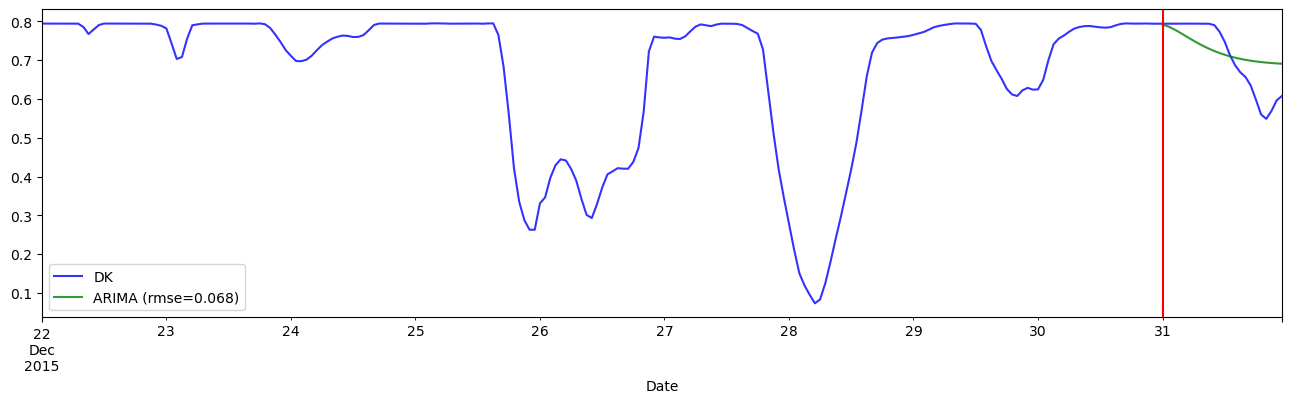

In [28]:
start = len(dfh_train)
end = len(dfh_train)+len(dfh_test)-1
dfh_pred = results.predict(start=start, end=end)
dfh_pred = dfh_pred.rename(f'ARIMA (rmse={np.sqrt(mean_squared_error(dfh_test, dfh_pred)):2.2})')

fig = plt.figure(figsize=(16,4))
ax = plt.gca()

dfh.plot(color='blue', alpha=0.8, ax=ax)
dfh_pred.plot(legend=True, alpha=0.8, color='green', ax=ax)
plt.axvline(dfh_test.index[0], color='red')

#### Build a LSTM model for month-ahead forecasting: use a sliding window of the previous 12 months to predict the next month.

In [29]:
tsg = tf.keras.preprocessing.sequence.TimeseriesGenerator

In [30]:
train = np.array(dfm_train['DK'])
test = np.array(dfm_test['DK'])

In [31]:
mytsg = tsg(train, train, length=12, batch_size=1) # predict next month from previous 12 months

In [32]:
mytsg[0]

(array([[0.55208547, 0.36956693, 0.39925734, 0.24684551, 0.36662692,
         0.23014688, 0.3164895 , 0.32547079, 0.45816385, 0.45244267,
         0.61058789, 0.54622247]]),
 array([0.51084015]))

In [33]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(12,1)))
model.add(tf.keras.layers.LSTM(128, return_sequences=True, activation='relu'))
model.add(tf.keras.layers.LSTM(64))
model.add(tf.keras.layers.Dense(32, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='mse')

In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

#### Train

In [35]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='loss',patience=20,restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='loss',factor=0.5,patience=5,min_lr=1e-6)
model.fit(mytsg, epochs=100, callbacks=[reduce_lr, early_stop])

Epoch 1/100


222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0142 - learning_rate: 0.0010
Epoch 2/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0135 - learning_rate: 0.0010
Epoch 3/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0133 - learning_rate: 0.0010
Epoch 4/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0101 - learning_rate: 0.0010
Epoch 5/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0073 - learning_rate: 0.0010
Epoch 6/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0063 - learning_rate: 0.0010
Epoch 7/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0087 - learning_rate: 0.0010
Epoch 8/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0075 - learning_rate: 0.0010
Epoch 9/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0082 - learning_rate: 0.0010
Epoch 10/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0063 - learning_rate: 0.0010
Epoch 11/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0064 - learning_ra

222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0056 - learning_rate: 1.5625e-05
Epoch 65/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0055 - learning_rate: 1.5625e-05
Epoch 66/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0061 - learning_rate: 1.5625e-05
Epoch 67/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0058 - learning_rate: 1.5625e-05
Epoch 68/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0054 - learning_rate: 7.8125e-06
Epoch 69/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0051 - learning_rate: 7.8125e-06
Epoch 70/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0063 - learning_rate: 7.8125e-06
Epoch 71/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0065 - learning_rate: 7.8125e-06
Epoch 72/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0050 - learning_rate: 7.8125e-06
Epoch 73/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0074 - learning_rate: 3.9063e-06
Epoch 74/100
222/222 ━━━━━━━━━━━━

#### Test

In [36]:
model.predict(train[-12:].reshape(1,12,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step


array([[0.29593566]], dtype=float32)

In [37]:
test[0]

np.float64(0.24033326612903227)

In [38]:
predictions = []

batch = train[-12:].reshape((1, 12, 1))

for i in range(len(test)):
    prediction = model.predict(batch)[0]
    predictions.append(prediction) 
    batch = np.append(batch[:,1:,:],[[prediction]],axis=1)
    
dfm_pred = pd.DataFrame(predictions, index=dfm_test.index, columns=["LSTM"])
dfm_pred = dfm_pred["LSTM"]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


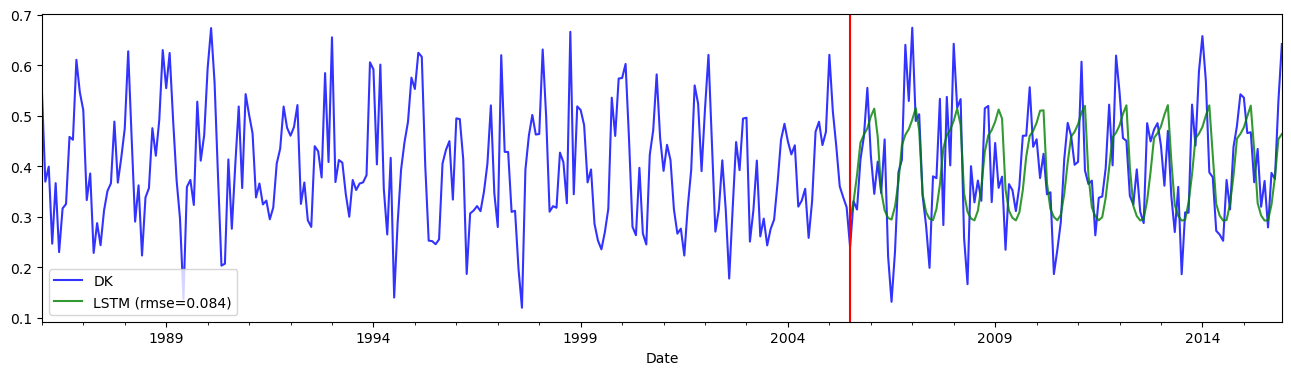

In [39]:
start = len(dfm_train)
end = len(dfm_train)+len(dfm_test)-1

dfm_pred = dfm_pred.rename(f'LSTM (rmse={np.sqrt(mean_squared_error(dfm_test, dfm_pred)):2.2})')

fig = plt.figure(figsize=(16,4))
ax = plt.gca()

dfm.plot(color='blue', alpha=0.8, ax=ax)
dfm_pred.plot(legend=True, alpha=0.8, color='green', ax=ax)
plt.axvline(dfm_test.index[0], color='red')

#### Build a LSTM model for hour-ahead forecasting: use a sliding window of the previous 24 hours to predict the next hour.

In [40]:
dfh = pd.DataFrame(df['DK'])
dfh = dfh.tail(24*10)
dfh.index.freq='h'
x = int(np.ceil(len(dfh)*(9.0/10.0)))
dfh_train = dfh[0:x]
dfh_test = dfh[x:]

In [41]:
tsg = tf.keras.preprocessing.sequence.TimeseriesGenerator

In [42]:
train = np.array(dfh_train['DK'])
test = np.array(dfh_test['DK'])

In [43]:
mytsg = tsg(train, train, length=24, batch_size=1) # predict next hour from previous 24 hours

In [44]:
mytsg[0]

(array([[0.79428, 0.79428, 0.79428, 0.79428, 0.79426, 0.79401, 0.79428,
         0.79408, 0.78564, 0.7673 , 0.77916, 0.79057, 0.79431, 0.79428,
         0.79428, 0.79428, 0.79428, 0.79428, 0.79428, 0.79429, 0.79435,
         0.79405, 0.79181, 0.78869]]),
 array([0.78184]))

In [45]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(24,1)))
model.add(tf.keras.layers.LSTM(128, return_sequences=True, activation='relu'))
model.add(tf.keras.layers.LSTM(64))
model.add(tf.keras.layers.Dense(32, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='mse')

In [46]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

#### Train

In [47]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='loss',patience=20,restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='loss',factor=0.5,patience=5,min_lr=1e-6)
model.fit(mytsg, epochs=100, callbacks=[reduce_lr, early_stop])

Epoch 1/100


192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0377 - learning_rate: 0.0010
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0203 - learning_rate: 0.0010
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0124 - learning_rate: 0.0010
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0083 - learning_rate: 0.0010
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0059 - learning_rate: 0.0010
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0033 - learning_rate: 0.0010
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0022 - learning_rate: 0.0010
Epoch 8/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0018 - learning_rate: 0.0010
Epoch 9/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0017 - learning_rate: 0.0010
Epoch 10/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0016 - learning_rate: 0.0010
Epoch 11/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0010 - learning_

192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 1.2733e-04 - learning_rate: 3.9063e-06
Epoch 63/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.5850e-04 - learning_rate: 3.9063e-06
Epoch 64/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.5350e-04 - learning_rate: 3.9063e-06
Epoch 65/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 1.4593e-04 - learning_rate: 3.9063e-06
Epoch 66/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.4313e-04 - learning_rate: 3.9063e-06
Epoch 67/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 2.1776e-04 - learning_rate: 1.9531e-06
Epoch 68/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.6152e-04 - learning_rate: 1.9531e-06
Epoch 69/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 1.1928e-04 - learning_rate: 1.9531e-06
Epoch 70/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 1.5840e-04 - learning_rate: 1.9531e-06
Epoch 71/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 1.8382e-04 - learning_rate: 1.95

#### Test

In [48]:
model.predict(train[-24:].reshape(1,24,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step


array([[0.7882962]], dtype=float32)

In [49]:
test[0]

np.float64(0.79395)

In [50]:
predictions = []

batch = train[-24:].reshape((1, 24, 1))

for i in range(len(test)):
    prediction = model.predict(batch)[0]
    predictions.append(prediction) 
    batch = np.append(batch[:,1:,:],[[prediction]],axis=1)
    
dfh_pred = pd.DataFrame(predictions, index=dfh_test.index, columns=["LSTM"])
dfh_pred = dfh_pred["LSTM"]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


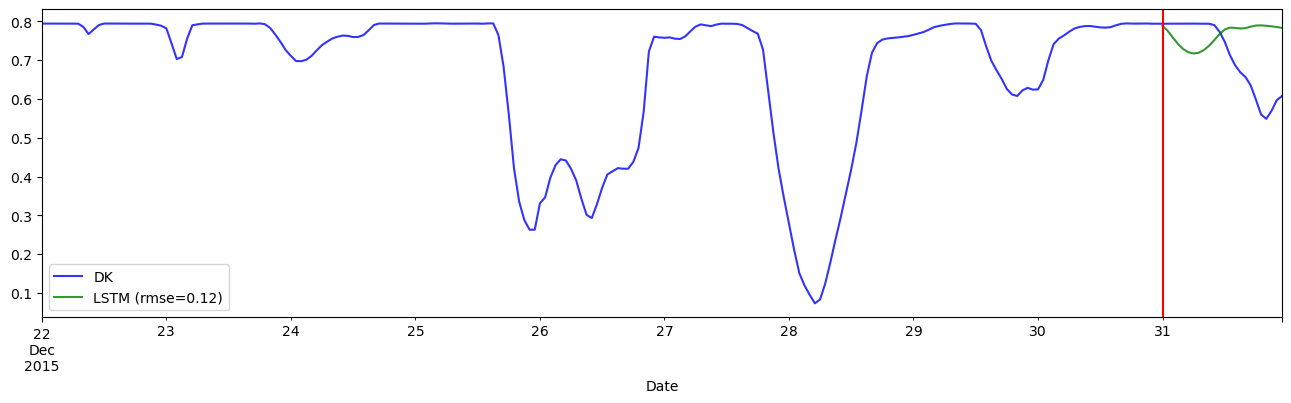

In [51]:
start = len(dfh_train)
end = len(dfh_train)+len(dfh_test)-1

dfh_pred = dfh_pred.rename(f'LSTM (rmse={np.sqrt(mean_squared_error(dfh_test, dfh_pred)):2.2})')

fig = plt.figure(figsize=(16,4))
ax = plt.gca()

dfh.plot(color='blue', alpha=0.8, ax=ax)
dfh_pred.plot(legend=True, alpha=0.8, color='green', ax=ax)
plt.axvline(dfh_test.index[0], color='red')

#### The LSTM and ARIMA models delivered similar forecast accuracy; ARIMA was slightly better, but the LSTM architecture was not extensively tuned as ARIMA was via auto_arima.